In [36]:
import random
import json
import re
import os, sys
from pathlib import Path
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix

WORK_DIR = Path.cwd().parent
sys.path.append(str(WORK_DIR))

from src import response_processing as rp
from src.viz_utils import qa_viz
from src.STAR_utils.visualization_tools import qa_visualization as qaviz

random.seed(6)
np.random.seed(6)

STAR_VAL_SMALL = WORK_DIR / "data/datasets/STAR/STAR_annotations/STAR_val_small_1000.json"

RAW_VIDEO_DIR = Path(WORK_DIR / 'data/datasets/action-genome/Charades_v1_480/')
SAVE_VIDEO_DIR = Path(WORK_DIR / "experiments/video_dump")


## Load GT

In [37]:
with open(STAR_VAL_SMALL, 'r') as f:
    gt_df = pd.read_json(f)

gt_df = gt_df.rename(columns={'answer': 'text'})
gt_df = gt_df.set_index('question_id')
gt_df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 1048 entries, Feasibility_T5_102 to Interaction_T4_4181
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   question          1048 non-null   object 
 1   video_id          1048 non-null   object 
 2   start             1048 non-null   float64
 3   end               1048 non-null   float64
 4   text              1048 non-null   object 
 5   question_program  1048 non-null   object 
 6   choices           1048 non-null   object 
 7   situations        1048 non-null   object 
dtypes: float64(2), object(6)
memory usage: 73.7+ KB


# Experiment 1

#### Comparison between Gemma3:4b and Gemini 2.5 flash on the Graph QA task on the STSG generated by Gemini 2.5 flash

In [103]:
GEMMA_RESPONSES_FPATH = WORK_DIR / "outputs/gqa_u3_gemma3:4b_on_gemini_stsg_1000_20250805_15:48:00.jsonl"
#GEMMA_RESPONSES_FPATH = WORK_DIR / "outputs/gqa_u3_gemma3:12b_on_gemini_stsg_1000_20250806_17:30:00.jsonl"
GEMINI_RESPONSES_FPATH = WORK_DIR / "scripts/data/aggregated_final_gu_u3_1000_on_geminiSGG_gemini25flash_20250805_15:48:00.jsonl"


In [104]:
gemma_pred_gg_df = rp.ans_extract(GEMMA_RESPONSES_FPATH, "gemma3", format="ollama")
gemini_pred_gg_df = rp.ans_extract(GEMINI_RESPONSES_FPATH, "gemma3", format="gemini")


Total answers: 1036
Answers following JSON template: 1036
Percentage following JSON template: 100.00%
Answer with a valid alternative: 941
90.83% of the total

Invalid answers: 95
Total answers: 1036
Answers following JSON template: 1021
Percentage following JSON template: 98.55%


/home/lusha/star_code/src/response_processing.py:184: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  contains_answer = predictions_df["answer"].str.contains(
Error executing eval on: {  "answer": "Based on the provided Spatio-Temporal Scene Graph, the person is shown seasoning a pancake that is \"placed on a cutting board on the counter.\" The STSG describes the action of seasoning the pancake but does not show the person physically manipulating the dish (pancake) by holding it, putting it down, or taking it. The narrative moves from seasoning to the person getting a glass and opening the refrigerator, without further interaction with the pancake itself. Therefore, none of the given alternatives are explicitly supported or directly inferable from the provided scene graph as actions the person *performs* with the dish within the described timeframe. The question asks what the person *is able to do*, 

Answer with a valid alternative: 702
68.76% of the total

Invalid answers: 319


/home/lusha/star_code/src/response_processing.py:184: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  contains_answer = predictions_df["answer"].str.contains(


In [105]:
for _, row in gemma_pred_gg_df[~gemma_pred_gg_df["contains_answer"]].iterrows():
    print(row["chat_history"][-1]["content"])


```json
{"answer": "None of the alternatives are supported by the scene graph. The scene graph describes the person’s actions with the bag – picking it up, emptying its contents into the bucket, and then picking up the mat. There is no mention of the person intending to throw anything."}
```
```json
{"answer": "None of the alternatives are supported by the scene graph."}
```
```json
{"answer": "None of the alternatives can be determined from the provided scene graph. Since the scene graph describes the man’s actions within the pantry – approaching the door, opening it, stepping into the opening, and lowering his head to look – it does not provide any information about what he is holding."}
```
```json
{"answer": "No answer is possible based on the provided Spatio-Temporal Scene Graph."}
```
```json
{"answer": "None of the above"}
```
```json
{"answer": "None of the alternatives are correct. The scene graph describes the person repeatedly tossing and catching a pink, rectangular object,

In [106]:
for _, row in gemini_pred_gg_df[~gemini_pred_gg_df["contains_answer"]].iterrows():
    print(row["chat_history"][-1]["content"])



```json
{"answer": "Based on the provided Spatio-Temporal Scene Graph, there is no mention or depiction of a window, nor any interaction the person has with one. The STSG exclusively describes the person's actions related to holding a book and turning on a light switch. Therefore, no logical inference can be made from the STSG about what the person is able to do with a window. As none of the alternatives (A. Lie on the window, B. Hold the window, C. Close the window, D. Open the window) are supported by the provided information, and I must choose an answer, this indicates a limitation or a mismatch between the question and the STSG data. However, since the task requires a choice, and without information, no logical choice is possible, I cannot provide a definitively supported answer from the STSG."}
```

{"answer": "There is not enough information in the STSG to answer the question."}

{
"answer": "There seems to be an inconsistency between the provided Spatio-Temporal Scene Graph (ST

In [107]:
gemma_pred_gg_df = gemma_pred_gg_df[gemma_pred_gg_df['contains_answer']]
gemini_pred_gg_df = gemini_pred_gg_df[gemini_pred_gg_df['contains_answer']]


In [108]:
gemma_pred_gg_df.rename(columns={'answer': 'pred_text'}, inplace=True)
gemma_eval_df = gt_df.join(
    gemma_pred_gg_df, 
    how='inner' # we account also for samples without answers
)
rp.print_acc(gemma_eval_df, lambda x: rp.accuracy(x, on_what='text'))


Question type       Total      Accuracy 

Interaction          283        62.54%  
Sequence             265        60.00%  
Prediction           209        52.63%  
Feasibility          184        55.98%  

Average              941        58.34%  


In [109]:
rp.print_ans_perc(gemma_eval_df, gt_df)


Question type       Total      Answered 

Interaction          298        94.97%  
Sequence             291        91.07%  
Prediction           239        87.45%  
Feasibility          220        83.64%  
Overall             1048        89.79%  


In [110]:
print(gemma_pred_gg_df.iloc[0]["chat_history"][1]["content"])


Okay, let's analyze the scene graph and answer the question.

1. **Question Interpretation:** The question asks which object the person is able to *throw* after entering the bedroom. This implies a dynamic action – throwing.

2. **STSG Analysis:** The scene graph describes a sequence of actions involving a person putting on a shirt. It details the person’s movements: holding a garment, unfolding it, putting it on, and pulling it over their head. There is no mention of any other objects being present or interacted with, let alone objects that could be thrown. The scene focuses entirely on the clothing change.

3. **Alternative Evaluation:**
   * **A. The bag:** The scene graph doesn't mention a bag.
   * **B. The book:** The scene graph doesn’t mention a book.
   * **C. The blanket:** The scene graph doesn’t mention a blanket.
   * **D. The clothes:** While the person *is* interacting with clothes, the question asks what they are able to *throw*. The scene graph doesn’t describe any thr

In [111]:
gemini_pred_gg_df.rename(columns={'answer': 'pred_text'}, inplace=True)
eval_df_gemini = gt_df.join(
    gemini_pred_gg_df, 
    how='inner' # we account also for samples without answers
)
rp.print_acc(eval_df_gemini, lambda x: rp.accuracy(x, on_what='text'))


Question type       Total      Accuracy 

Interaction          224        74.11%  
Sequence             190        74.74%  
Prediction           143        66.43%  
Feasibility          145        57.24%  

Average              702        69.23%  


In [112]:
rp.print_ans_perc(eval_df_gemini, gt_df)


Question type       Total      Answered 

Interaction          298        75.17%  
Sequence             291        65.29%  
Prediction           239        59.83%  
Feasibility          220        65.91%  
Overall             1048        66.98%  


In [113]:
gemini_pred_gg_df.iloc[0].keys()


Index(['chat_history', 'contains_answer', 'pred_text'], dtype='object')

In [114]:
print(gemini_pred_gg_df.iloc[0]['chat_history'][1]['content'])



1. **Question Interpretation:** The question asks to identify which object the person is able to throw *after* walking through the doorway, based on the provided Spatio-Temporal Scene Graph description.

2. **STSG Analysis:** The STSG describes a sequence of actions involving a person and a garment (clothes) in a bedroom doorway, specifically in relation to a closet.
    - **Image 0:** The person holds a dark-colored garment (jersey) in her left hand, appearing to retrieve it from a cluttered closet.
    - **Image 1:** The person holds the same garment more centrally with both hands, appearing to unfold or prepare it.
    - **Image 2:** The person initiates putting on the garment; arms are blurred, garment no longer clearly visible in hands due to motion.
    - **Image 3:** The person is actively in the process of donning the garment, which now appears to be a long-sleeved black shirt or hoodie, pulling it over her head and shoulders.
    The entire sequence revolves around the person

In [115]:
gemma_pred_gg_df.rename(columns={'pred_text': 'pred_text1'}, inplace=True)
gemini_pred_gg_df.rename(columns={'pred_text': 'pred_text2'}, inplace=True)
eval_df_all = gt_df.join(
    gemma_pred_gg_df[['pred_text1']],
    how='inner'
).join(
    gemini_pred_gg_df[['pred_text2']],
    how='inner'
)

eval_df_all['text'] = eval_df_all['text'].str.lower()
eval_df_all['pred_text1'] = eval_df_all['pred_text1'].str.lower()
eval_df_all['pred_text2'] = eval_df_all['pred_text2'].str.lower()
eval_df_all[['question', 'text', 'pred_text1', 'pred_text2']]


,question,text,pred_text1,pred_text2
Feasibility_T5_102,Which object is the person able to throw after...,the clothes.,the clothes.,the clothes.
Interaction_T1_5612,Which object was opened by the person?,the laptop.,the laptop.,the laptop.
Sequence_T5_4571,What did the person do to the clothes after si...,put down.,put down.,put down.
Prediction_T1_499,What will the person do next?,put down the shoe.,sit on the sofa/couch.,put down the bag.
Interaction_T2_6234,What did the person do with the table?,sat at.,sat at.,sat at.
...,...,...,...,...
Interaction_T1_7254,Which object was taken by the person?,the pillow.,the clothes.,the clothes.
Interaction_T1_8274,Which object was taken by the person?,the dish.,the dish.,the dish.
Interaction_T1_8913,Which object was taken by the person?,the paper/notebook.,the paper/notebook.,the paper/notebook.
Interaction_T2_1847,What did the person do with the paper/notebook?,took.,took.,took.


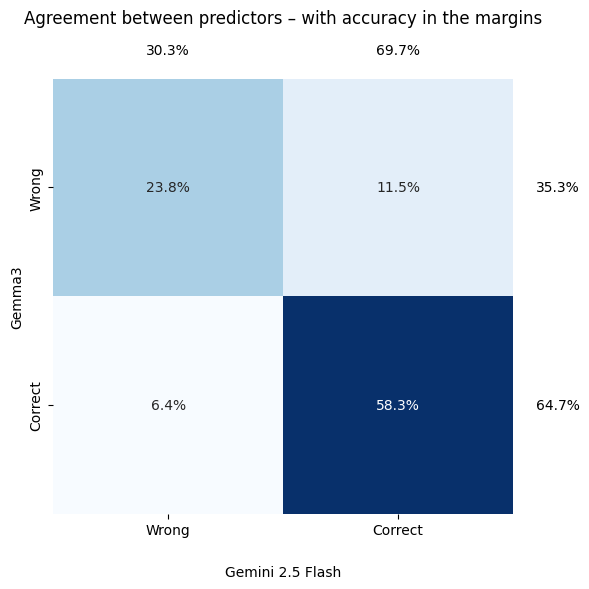

(671, 10)


In [116]:
# your data
display_eval = eval_df_all
pred_vqa_correct = (display_eval['text'] == display_eval['pred_text1']).astype(int).values
pred_gg_correct  = (display_eval['text'] == display_eval['pred_text2']).astype(int).values
labels = ['Wrong', 'Correct']

# confusion matrix (normalized over all)
cm = confusion_matrix(pred_vqa_correct, pred_gg_correct, normalize='all')

# compute marginal sums and convert to % of total
row_totals = cm.sum(axis=1)
col_totals = cm.sum(axis=0)
total = cm.sum()
row_pct = row_totals / total
col_pct = col_totals / total

fig, ax = plt.subplots(figsize=(6, 6))
sns.heatmap(cm, annot=True, fmt='.1%', cmap='Blues',
            xticklabels=labels, yticklabels=labels,
            cbar=False, ax=ax)

# annotate row marginals at the right of each row
for i, p in enumerate(row_pct):
    ax.text(len(labels) + 0.1,  i + 0.5, f'{p:.1%}', 
            va='center', ha='left', fontsize=10)

# annotate column marginals just above each column
for j, p in enumerate(col_pct):
    ax.text(j + 0.5, -0.1, f'{p:.1%}', 
            ha='center', va='bottom', fontsize=10)

# move x-axis labels (and xlabel) to the top
ax.set_xlabel('Gemini 2.5 Flash', labelpad=20)
ax.set_ylabel('Gemma3')
ax.set_title('Agreement between predictors – with accuracy in the margins', pad=40)

# make xtick labels horizontal
ax.set_xticklabels(labels, rotation=0)

plt.tight_layout()
plt.show()
print(eval_df_all.shape)


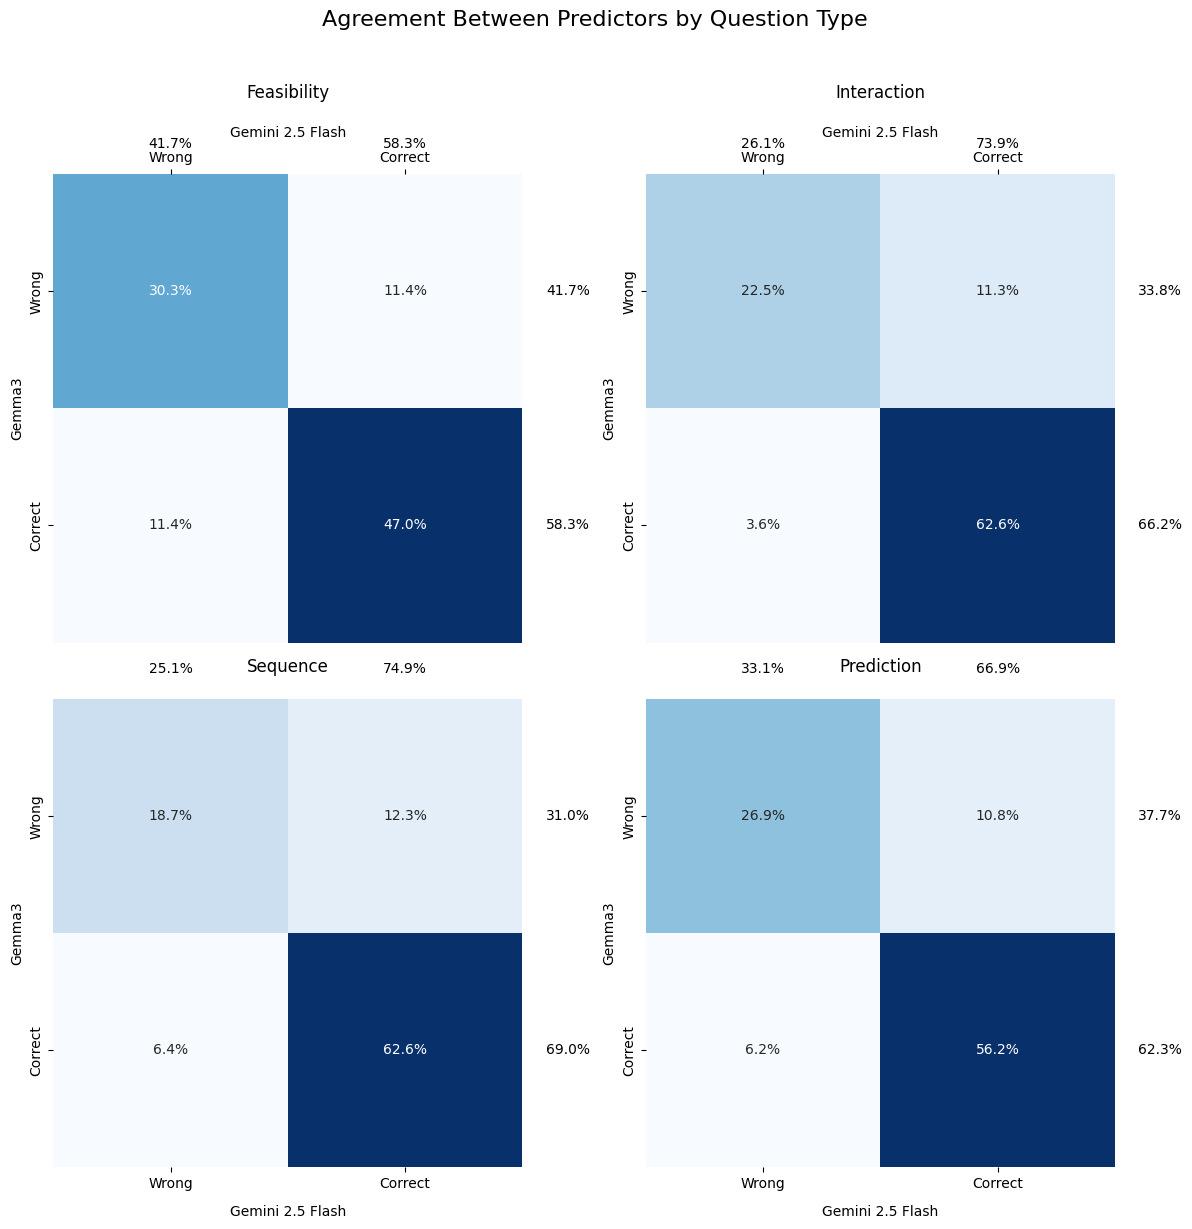

In [117]:
# Create a copy of the DataFrame for visualization
viz_df = eval_df_all.copy()

# Extract question type from the index
viz_df['question_type'] = viz_df.index.str.split('_').str[0]

# Get unique question types
question_types = viz_df['question_type'].unique()

# Set up the plot grid
fig, axes = plt.subplots(2, 2, figsize=(12, 12))
fig.suptitle('Agreement Between Predictors by Question Type', y=1.02, fontsize=16)

# Flatten axes for easy iteration
axes = axes.flatten()

for i, qtype in enumerate(question_types):
    # Filter data for this question type
    subset = viz_df[viz_df['question_type'] == qtype]
    
    # Calculate correctness
    pred_vqa_correct = (subset['text'] == subset['pred_text1']).astype(int).values
    pred_gg_correct = (subset['text'] == subset['pred_text2']).astype(int).values
    
    # Confusion matrix (normalized over all)
    cm = confusion_matrix(pred_vqa_correct, pred_gg_correct, normalize='all')
    
    # Compute marginal sums
    row_totals = cm.sum(axis=1)
    col_totals = cm.sum(axis=0)
    total = cm.sum()
    row_pct = row_totals / total
    col_pct = col_totals / total
    
    # Create heatmap
    sns.heatmap(cm, annot=True, fmt='.1%', cmap='Blues',
                xticklabels=labels, yticklabels=labels,
                cbar=False, ax=axes[i])
    
    # Annotate row marginals
    for j, p in enumerate(row_pct):
        axes[i].text(len(labels) + 0.1, j + 0.5, f'{p:.1%}', 
                    va='center', ha='left', fontsize=10)
    
    # Annotate column marginals
    for k, p in enumerate(col_pct):
        axes[i].text(k + 0.5, -0.1, f'{p:.1%}', 
                    ha='center', va='bottom', fontsize=10)
    
    # Customize subplot
    axes[i].set_title(qtype, pad=20)
    axes[i].set_xlabel('Gemini 2.5 Flash', labelpad=10)
    axes[i].set_ylabel('Gemma3')
    axes[i].set_xticklabels(labels, rotation=0)
    
    # Move x-axis to top for all but bottom row
    if i < 2:  # Top row
        axes[i].xaxis.set_ticks_position('top')
        axes[i].xaxis.set_label_position('top')

plt.tight_layout()
plt.show()


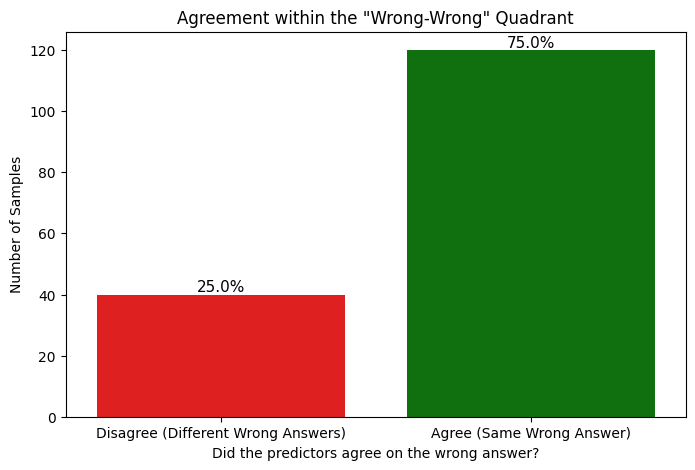

In [118]:
wrong_wrong_df = eval_df_all[
    (eval_df_all['text'] != eval_df_all['pred_text1']) &
    (eval_df_all['text'] != eval_df_all['pred_text2'])
].copy()

wrong_wrong_df['agreement_on_wrong'] = (
    wrong_wrong_df['pred_text1'] == wrong_wrong_df['pred_text2']
)

# Visualize the result
plt.figure(figsize=(8, 5))
ax = sns.countplot(
    data=wrong_wrong_df,
    x='agreement_on_wrong',
    hue='agreement_on_wrong',
    palette=['Red', 'Green'],
    legend=False
)

plt.title('Agreement within the "Wrong-Wrong" Quadrant')
plt.ylabel('Number of Samples')
plt.xlabel('Did the predictors agree on the wrong answer?')
ax.set_xticks([0, 1]) 
ax.set_xticklabels(['Disagree (Different Wrong Answers)', 'Agree (Same Wrong Answer)'])

# Add percentage annotations
total = len(wrong_wrong_df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(percentage, (x, y), ha='center', va='bottom', fontsize=11)

plt.show()


/tmp/ipykernel_877957/1012052540.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


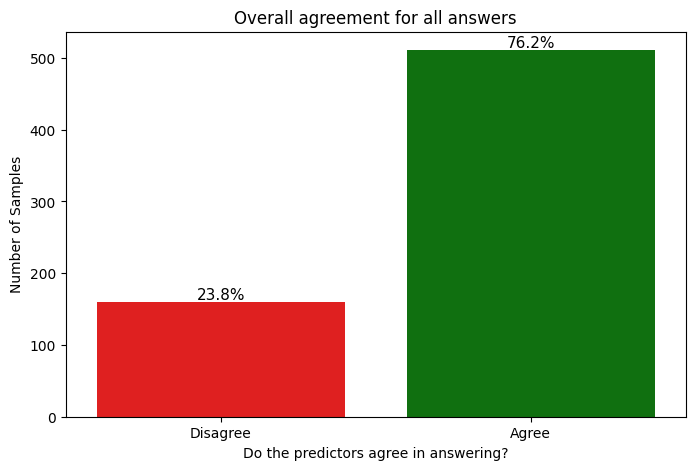

In [119]:
agreement_df = pd.DataFrame((eval_df_all['pred_text1'] == eval_df_all['pred_text2']), columns=['agreement'])

# Visualize the result
plt.figure(figsize=(8, 5))
ax = sns.countplot(
    data=agreement_df,
    x='agreement',
    palette=['Red', 'Green']
)

plt.title('Overall agreement for all answers')
plt.ylabel('Number of Samples')
plt.xlabel('Do the predictors agree in answering?')
ax.set_xticks([0, 1]) 
ax.set_xticklabels(['Disagree', 'Agree'])

# Add percentage annotations
total = len(agreement_df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(percentage, (x, y), ha='center', va='bottom', fontsize=11)

plt.show()


/tmp/ipykernel_877957/1369200679.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(
/tmp/ipykernel_877957/1369200679.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(
/tmp/ipykernel_877957/1369200679.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(
/tmp/ipykernel_877957/1369200679.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


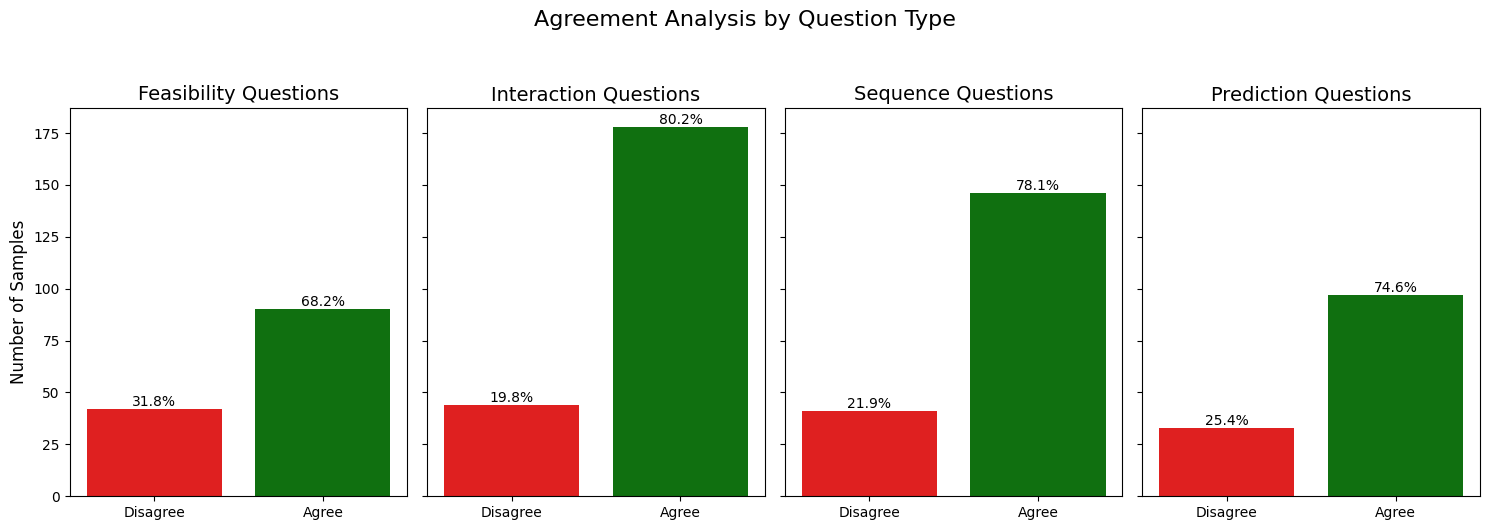

In [120]:
# Create a copy of the DataFrame for visualization
viz_df = eval_df_all.copy()

# Extract question type from the index
viz_df['question_type'] = viz_df.index.str.split('_').str[0]

# Create agreement column in the copy
viz_df['agreement'] = viz_df['pred_text1'] == viz_df['pred_text2']

# Get unique question types
question_types = viz_df['question_type'].unique()
n_types = len(question_types)

# Create subplots
fig, axes = plt.subplots(1, n_types, figsize=(15, 5), sharey=True)
fig.suptitle('Agreement Analysis by Question Type', fontsize=16, y=1.05)

for i, qtype in enumerate(question_types):
    # Filter data for this question type
    subset = viz_df[viz_df['question_type'] == qtype]
    
    # Create countplot
    ax = sns.countplot(
        data=subset,
        x='agreement',
        palette=['Red', 'Green'],
        ax=axes[i]
    )
    
    # Set title and labels
    ax.set_title(f'{qtype} Questions', fontsize=14)
    ax.set_xlabel('')
    if i == 0:
        ax.set_ylabel('Number of Samples', fontsize=12)
    
    # Set x-ticks
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Disagree', 'Agree'])
    
    # Add percentage annotations
    total = len(subset)
    for p in ax.patches:
        percentage = f'{100 * p.get_height() / total:.1f}%'
        x = p.get_x() + p.get_width() / 2
        y = p.get_height()
        ax.annotate(percentage, (x, y), ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()


# Experiment 2
### Comparing Gemini (2.5 flash) VQA on interactive vs batch mode

In [ ]:
VQA_RESP_FILEPATH_INTERACTIVE = WORK_DIR / "notebooks/gemini_vqa_small200_20250722_15:44:00.jsonl" #Qwen2.5VL 1000 samples
VQA_RESP_FILEPATH_BATCH = WORK_DIR / "scripts/data/vqa_gemini_flash_full_chat_history.jsonl" #Qwen2.5VL GQA on Qwen SGG


In [ ]:
# To extract the answers in the interactive mode I'm using the ollama format because I formatted
# the output structure myself when i was receiving the messages

interactive_pred_gg_df = rp.ans_extract(VQA_RESP_FILEPATH_INTERACTIVE, "gemma3", format="ollama")
batch_pred_gg_df = rp.ans_extract(VQA_RESP_FILEPATH_BATCH, "gemma3", format="gemini")


Total answers: 125
Answers following JSON template: 125
Percentage following JSON template: 100.00%
Answer with a valid alternative: 114
91.20% of the total

Invalid answers: 11


/home/lusha/star_code/src/response_processing.py:184: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  contains_answer = predictions_df["answer"].str.contains(
Error executing eval on: {  "answer": "The video shows the person opening a door and walking into another room. Subsequently, in the new room, the person approaches a desk and picks up a flat, circular object, which they then bring to their mouth. None of the provided alternatives perfectly align with the visual evidence as *immediately* after opening the door, the person simply walks through. However, looking at the subsequent distinct action sequence in the video after the door is opened and the person moves to the next room, the person picks up an item from the desk. The item is a flat, circular disk, not explicitly a shoe, sandwich, paper/notebook, or another closet/cabinet. Given the provided choices and the action of taking an object and 

Total answers: 200
Answers following JSON template: 195
Percentage following JSON template: 97.50%
Answer with a valid alternative: 175
89.74% of the total

Invalid answers: 20


/home/lusha/star_code/src/response_processing.py:184: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  contains_answer = predictions_df["answer"].str.contains(


In [ ]:
interactive_pred_gg_df = interactive_pred_gg_df[interactive_pred_gg_df['contains_answer']]
batch_pred_gg_df = batch_pred_gg_df[batch_pred_gg_df['contains_answer']]


In [ ]:
interactive_pred_gg_df.rename(columns={'answer': 'pred_text'}, inplace=True)
eval_df1 = gt_df.join(
    interactive_pred_gg_df, 
    how='inner' # we account also for samples without answers
)
rp.print_acc(eval_df1, lambda x: rp.accuracy(x, on_what='text'))


Question type       Total      Accuracy 

Interaction          33         81.82%  
Sequence             25         88.00%  
Prediction           32         75.00%  
Feasibility          24         41.67%  

Average              114        72.81%  


In [ ]:
rp.print_ans_perc(eval_df1, gt_df)


Question type       Total      Answered 

Interaction          50         66.00%  
Sequence             50         50.00%  
Prediction           50         64.00%  
Feasibility          50         48.00%  
Overall              200        57.00%  


In [ ]:
batch_pred_gg_df.rename(columns={'answer': 'pred_text'}, inplace=True)
eval_df2 = gt_df.join(
    batch_pred_gg_df, 
    how='inner' # we account also for samples without answers
)
rp.print_acc(eval_df2, lambda x: rp.accuracy(x, on_what='text'))


Question type       Total      Accuracy 

Interaction          49         83.67%  
Sequence             44         84.09%  
Prediction           41         73.17%  
Feasibility          41         41.46%  

Average              175        71.43%  


In [ ]:
rp.print_ans_perc(batch_pred_gg_df, gt_df)


Question type       Total      Answered 

Interaction          50         98.00%  
Sequence             50         88.00%  
Prediction           50         82.00%  
Feasibility          50         82.00%  
Overall              200        87.50%  


In [ ]:
interactive_pred_gg_df.rename(columns={'pred_text': 'pred_text1'}, inplace=True)
batch_pred_gg_df.rename(columns={'pred_text': 'pred_text2'}, inplace=True)
eval_df_all = gt_df.join(
    interactive_pred_gg_df[['pred_text1']],
    how='inner'
).join(
    batch_pred_gg_df[['pred_text2']],
    how='inner'
)

eval_df_all['text'] = eval_df_all['text'].str.lower()
eval_df_all['pred_text1'] = eval_df_all['pred_text1'].str.lower()
eval_df_all['pred_text2'] = eval_df_all['pred_text2'].str.lower()
eval_df_all[['question', 'text', 'pred_text1', 'pred_text2']]


,question,text,pred_text1,pred_text2
Prediction_T1_2102,What will the person do next?,close the refrigerator.,close the refrigerator.,close the refrigerator.
Interaction_T4_3931,What did the person do while they were sitting...,opened the closet/cabinet.,opened the closet/cabinet.,opened the closet/cabinet.
Interaction_T1_9123,Which object was opened by the person?,the refrigerator.,the refrigerator.,the refrigerator.
Prediction_T1_2737,What will the person do next?,open the laptop.,open the laptop.,take the phone/camera.
Prediction_T3_495,Which object would the person take next?,the clothes.,the bag.,the bag.
...,...,...,...,...
Interaction_T1_6336,Which object was put down by the person?,the laptop.,the laptop.,the laptop.
Sequence_T6_3033,What did the person do to the cup/glass/bottle...,took.,took.,took.
Interaction_T3_2531,What did the person do while they were holding...,put down the bag.,opened the bag.,opened the bag.
Sequence_T2_521,Which object did the person take before they h...,the blanket.,the blanket.,the blanket.


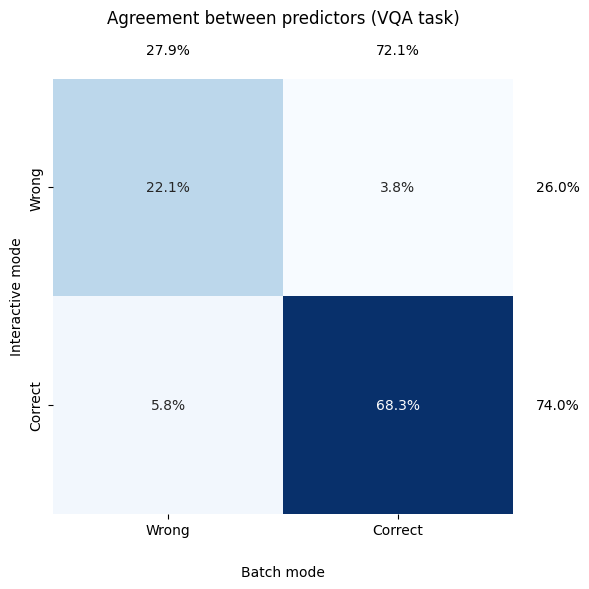

(104, 10)


In [ ]:
# your data
display_eval = eval_df_all
pred_vqa_correct = (display_eval['text'] == display_eval['pred_text1']).astype(int).values
pred_gg_correct  = (display_eval['text'] == display_eval['pred_text2']).astype(int).values
labels = ['Wrong', 'Correct']

# confusion matrix (normalized over all)
cm = confusion_matrix(pred_vqa_correct, pred_gg_correct, normalize='all')

# compute marginal sums and convert to % of total
row_totals = cm.sum(axis=1)
col_totals = cm.sum(axis=0)
total = cm.sum()
row_pct = row_totals / total
col_pct = col_totals / total

fig, ax = plt.subplots(figsize=(6, 6))
sns.heatmap(cm, annot=True, fmt='.1%', cmap='Blues',
            xticklabels=labels, yticklabels=labels,
            cbar=False, ax=ax)

# annotate row marginals at the right of each row
for i, p in enumerate(row_pct):
    ax.text(len(labels) + 0.1,  i + 0.5, f'{p:.1%}', 
            va='center', ha='left', fontsize=10)

# annotate column marginals just above each column
for j, p in enumerate(col_pct):
    ax.text(j + 0.5, -0.1, f'{p:.1%}', 
            ha='center', va='bottom', fontsize=10)

# move x-axis labels (and xlabel) to the top
ax.set_xlabel('Batch mode', labelpad=20)
ax.set_ylabel('Interactive mode')
ax.set_title('Agreement between predictors (VQA task)', pad=40)

# make xtick labels horizontal
ax.set_xticklabels(labels, rotation=0)

plt.tight_layout()
plt.show()
print(eval_df_all.shape)


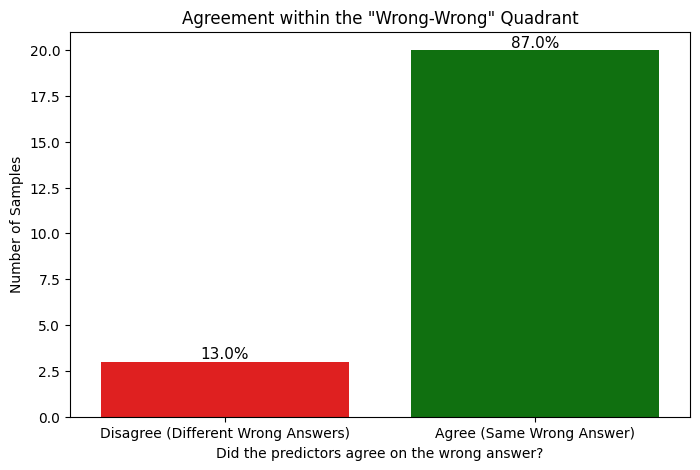

In [ ]:
wrong_wrong_df = eval_df_all[
    (eval_df_all['text'] != eval_df_all['pred_text1']) &
    (eval_df_all['text'] != eval_df_all['pred_text2'])
].copy()

wrong_wrong_df['agreement_on_wrong'] = (
    wrong_wrong_df['pred_text1'] == wrong_wrong_df['pred_text2']
)

# Visualize the result
plt.figure(figsize=(8, 5))
ax = sns.countplot(
    data=wrong_wrong_df,
    x='agreement_on_wrong',
    hue='agreement_on_wrong',
    palette=['Red', 'Green'],
    legend=False
)

plt.title('Agreement within the "Wrong-Wrong" Quadrant')
plt.ylabel('Number of Samples')
plt.xlabel('Did the predictors agree on the wrong answer?')
ax.set_xticks([0, 1]) 
ax.set_xticklabels(['Disagree (Different Wrong Answers)', 'Agree (Same Wrong Answer)'])

# Add percentage annotations
total = len(wrong_wrong_df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(percentage, (x, y), ha='center', va='bottom', fontsize=11)

plt.show()


/tmp/ipykernel_187418/1012052540.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


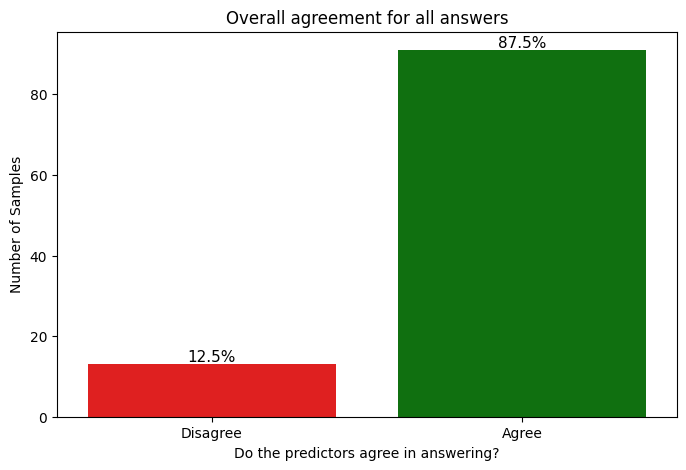

In [ ]:
agreement_df = pd.DataFrame((eval_df_all['pred_text1'] == eval_df_all['pred_text2']), columns=['agreement'])

# Visualize the result
plt.figure(figsize=(8, 5))
ax = sns.countplot(
    data=agreement_df,
    x='agreement',
    palette=['Red', 'Green']
)

plt.title('Overall agreement for all answers')
plt.ylabel('Number of Samples')
plt.xlabel('Do the predictors agree in answering?')
ax.set_xticks([0, 1]) 
ax.set_xticklabels(['Disagree', 'Agree'])

# Add percentage annotations
total = len(agreement_df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(percentage, (x, y), ha='center', va='bottom', fontsize=11)

plt.show()


/tmp/ipykernel_187418/1369200679.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(
/tmp/ipykernel_187418/1369200679.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(
/tmp/ipykernel_187418/1369200679.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(
/tmp/ipykernel_187418/1369200679.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


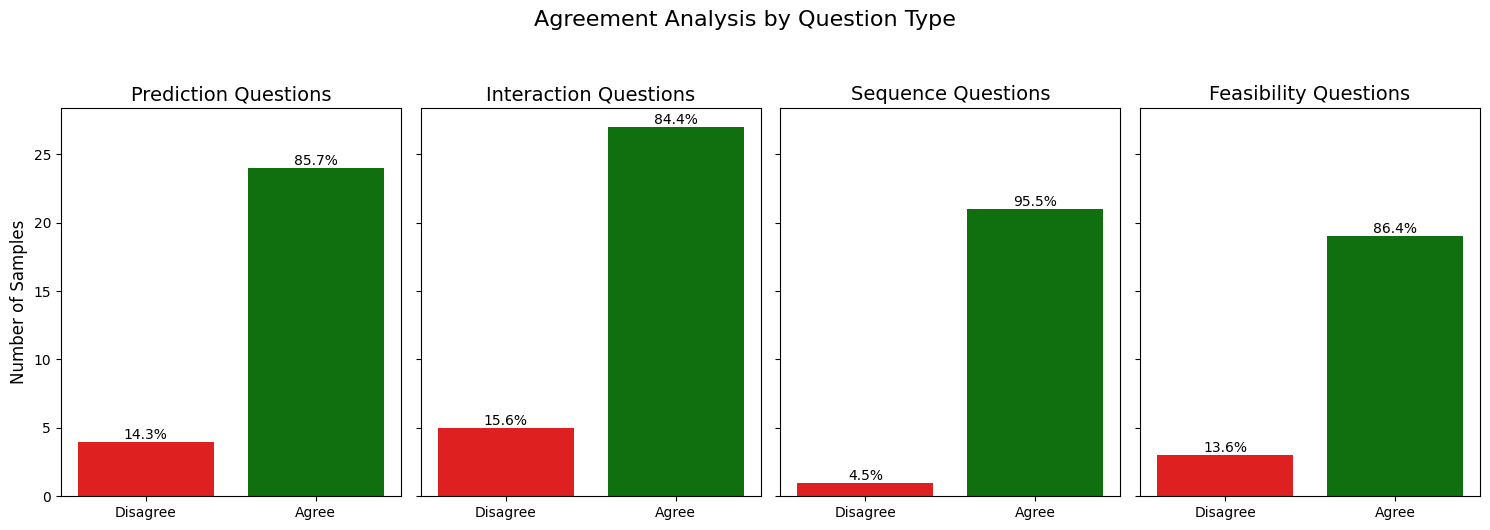

In [ ]:
# Create a copy of the DataFrame for visualization
viz_df = eval_df_all.copy()

# Extract question type from the index
viz_df['question_type'] = viz_df.index.str.split('_').str[0]

# Create agreement column in the copy
viz_df['agreement'] = viz_df['pred_text1'] == viz_df['pred_text2']

# Get unique question types
question_types = viz_df['question_type'].unique()
n_types = len(question_types)

# Create subplots
fig, axes = plt.subplots(1, n_types, figsize=(15, 5), sharey=True)
fig.suptitle('Agreement Analysis by Question Type', fontsize=16, y=1.05)

for i, qtype in enumerate(question_types):
    # Filter data for this question type
    subset = viz_df[viz_df['question_type'] == qtype]
    
    # Create countplot
    ax = sns.countplot(
        data=subset,
        x='agreement',
        palette=['Red', 'Green'],
        ax=axes[i]
    )
    
    # Set title and labels
    ax.set_title(f'{qtype} Questions', fontsize=14)
    ax.set_xlabel('')
    if i == 0:
        ax.set_ylabel('Number of Samples', fontsize=12)
    
    # Set x-ticks
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Disagree', 'Agree'])
    
    # Add percentage annotations
    total = len(subset)
    for p in ax.patches:
        percentage = f'{100 * p.get_height() / total:.1f}%'
        x = p.get_x() + p.get_width() / 2
        y = p.get_height()
        ax.annotate(percentage, (x, y), ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()
